# Do SVs / indels add climate-adaptive information beyond SNPs?
## Partial-RDA variance partitioning by variant class (SNP / indel / SV / ALL)

Instead of hunting individual loci (null under isolation-by-environment), we ask **how much of each variant class's among-site allele-frequency variance is explained by climate, net of population structure**, and whether adding indels/SVs to SNPs explains any climate variance the SNPs can't.

## Exactly what we ran

**Method:** partial Redundancy Analysis (pRDA) variance partitioning ([Capblancq & Forester 2021, *Meth. Ecol. Evol.*](https://besjournals.onlinelibrary.wiley.com/doi/full/10.1111/2041-210X.13722)), implemented in numpy (`rdavp_varpart.py`; `vegan` not used — hangs on Savio NFS).

| component | choice |
|---|---|
| **Response Y** | site allele frequencies, `[31 sites × L]` per class (plot AF aggregated to site by **flower-weighted mean**), each variant **column-centered** — *no* Hellinger, *no* scaling, *no* depth-weighting (kMate AF is calibrated / equal-precision) |
| **Predictor X (climate)** | PCA of the 19 standardized bioclim vars across the 31 sites; **3 PCs** kept by **broken-stick** (cum. var 0.82) |
| **Covariate Z (structure)** | top **3 SNP-PCA axes** (PCA of the SNP site-AF matrix) — the *same* covariate conditions **every** class, so the confound cancels in the class contrast |
| **Classes** | SNP · smallindel · SV · ALL (SNP+indel+SV stacked) |
| **MAF filter** | site-level MAF ≥ **0.05** (primary) + ≥ **0.01** (sensitivity), identical for all classes; invariant sites dropped |
| **Statistics** | **pure-climate R²** = constrained variance of Y (residualized on Z) explained by X (residualized on Z); **adjusted R²** (Ezekiel, n=31, conditioned df); **confounded** = full-climate R² − pure-climate R²; **permutation p** = permute the 31 climate rows ×2000, recompute constrained variance |
| **n** | **31 sites** is the true sample size (not the 355 plots — pseudoreplication) |

**Constrained variance** uses the identity `SS_constrained = trace(Hx · G)` with `G = Yz·Yzᵀ` (31×31) precomputed and `Hx` the climate hat-matrix — so 2000 permutations are near-instant.

**Code audit (`rdavp_audit.py`) — passed:** Gram-trick identity exact; **positive control** (response built from climate) → R²=0.99, p=0.0005 (detects real signal); **negative control** (random response) → R²=0.100 = null expectation p/(n−1), uniform permutation p; site-AF aggregation matches manual; confounded ≥ 0.

## Results

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, matplotlib as mpl
mpl.rcParams.update({'figure.dpi':110,'font.size':10,'axes.spines.top':False,'axes.spines.right':False})
OUT='/global/scratch/users/tbellg/kmate/results/grenenet_gea/gea_newpanel/rda_varpart'
df=pd.read_csv(f'{OUT}/varpart_by_class.csv')
df

,maf,cls,L,kclim,kstruct,pure_climate_R2,pure_climate_R2adj,perm_p,full_climate_R2,confounded
0,0.05,snp,1948677,3,3,0.1126,0.0016,0.4373,0.1764,0.0638
1,0.05,smallindel,650861,3,3,0.1097,-0.0016,0.4978,0.1741,0.0644
2,0.05,sv,27194,3,3,0.1078,-0.0037,0.5422,0.1707,0.0629
3,0.05,all,2626732,3,3,0.1118,0.0008,0.4518,0.1758,0.0640
4,0.01,snp,1991825,3,3,0.1124,0.0014,0.4433,0.1769,0.0645
5,0.01,smallindel,664615,3,3,0.1095,-0.0018,0.4993,0.1745,0.0650
6,0.01,sv,28260,3,3,0.1078,-0.0037,0.5437,0.1714,0.0637
7,0.01,all,2684700,3,3,0.1116,0.0006,0.4558,0.1762,0.0646


### Variance-partition figure
Each bar = climate-explained among-site variance, split into the **confounded** (climate∩structure) fraction and the **pure-climate** fraction (net of structure). Adjusted R² and permutation p annotated. MAF≥0.05.

null expectation for pure-climate R² (no signal) = kc/(n-kz-1) = 0.111
wrote /global/scratch/users/tbellg/kmate/results/grenenet_gea/gea_newpanel/rda_varpart/varpart_by_class.png


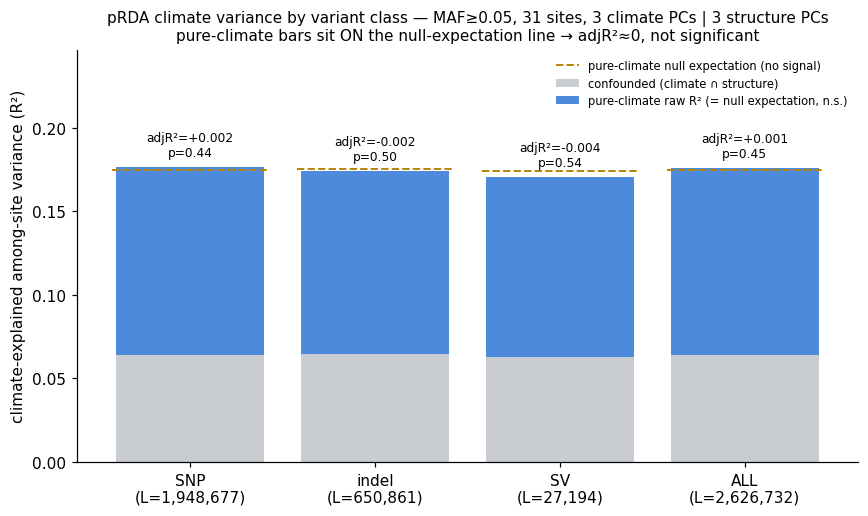

In [2]:
d=df[df.maf==0.05].set_index('cls').loc[['snp','smallindel','sv','all']]
lab={'snp':'SNP','smallindel':'indel','sv':'SV','all':'ALL'}
kc=int(d.kclim.iloc[0]); kz=int(d.kstruct.iloc[0]); n=31
null_exp=kc/(n-kz-1)   # E[pure-climate R²] under NO signal (overfitting expectation)
x=np.arange(len(d)); fig,ax=plt.subplots(figsize=(8,4.8))
conf=d.confounded.values; pure=d.pure_climate_R2.values
ax.bar(x,conf,color='#c9ccd1',label='confounded (climate ∩ structure)')
ax.bar(x,pure,bottom=conf,color='#3b7dd8',alpha=0.9,label='pure-climate raw R² (= null expectation, n.s.)')
# dashed line = the pure-climate R² EXPECTED under no signal; bars sit on it -> not real
for i in range(len(d)):
    ax.plot([i-0.42,i+0.42],[conf[i]+null_exp]*2,ls='--',lw=1.3,color='#b8860b',
            label=('pure-climate null expectation (no signal)' if i==0 else None))
for i,(c,r) in enumerate(d.iterrows()):
    ax.text(i, conf[i]+pure[i]+0.005, f"adjR²={r.pure_climate_R2adj:+.3f}\np={r.perm_p:.2f}",
            ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{lab[c]}\n(L={int(d.loc[c,"L"]):,})' for c in d.index])
ax.set_ylabel('climate-explained among-site variance (R²)')
ax.set_ylim(0, d.full_climate_R2.max()*1.4)
ax.set_title('pRDA climate variance by variant class — MAF≥0.05, 31 sites, 3 climate PCs | 3 structure PCs\n'
             'pure-climate bars sit ON the null-expectation line → adjR²≈0, not significant',fontsize=10)
ax.legend(loc='upper right',fontsize=7.5,frameon=False)
fig.tight_layout(); fig.savefig(f'{OUT}/varpart_by_class.png',dpi=150,bbox_inches='tight')
print(f'null expectation for pure-climate R² (no signal) = kc/(n-kz-1) = {null_exp:.3f}')
print('wrote',f'{OUT}/varpart_by_class.png'); plt.show()

In [3]:
# headline: does adding indels+SVs to SNPs add pure-climate information?
for thr in [0.05,0.01]:
    t=df[df.maf==thr].set_index('cls')
    add=t.loc['all','pure_climate_R2adj']-t.loc['snp','pure_climate_R2adj']
    print(f'MAF>={thr}: pure-climate adjR²  SNP={t.loc["snp","pure_climate_R2adj"]:+.4f}  '
          f'indel={t.loc["smallindel","pure_climate_R2adj"]:+.4f}  '
          f'SV={t.loc["sv","pure_climate_R2adj"]:+.4f}  ALL={t.loc["all","pure_climate_R2adj"]:+.4f}  '
          f'| ALL−SNP={add:+.4f}')

MAF>=0.05: pure-climate adjR²  SNP=+0.0016  indel=-0.0016  SV=-0.0037  ALL=+0.0008  | ALL−SNP=-0.0008
MAF>=0.01: pure-climate adjR²  SNP=+0.0014  indel=-0.0018  SV=-0.0037  ALL=+0.0006  | ALL−SNP=-0.0008


## Read-out
1. **All classes are interchangeable** — SNP, indel, SV and ALL explain the *same* climate variance (full ≈0.176, confounded ≈0.064, pure adjusted ≈0) at both MAF cuts.
2. **Adding indels+SVs to SNPs adds nothing** — `ALL − SNP ≈ 0` (pure-climate adjusted R²). In the variance-explained framing, **SVs/indels carry no climate information beyond SNPs** (fully redundant / SNP-tagged — consistent with the SV-heritability literature and prior 'SVs are passengers' results).
3. **Net of structure there is no significant climate signal for any class** — pure-climate adjusted R² ≈ 0, permutation **p ≈ 0.44–0.54**. Of the ~17.6% of among-site variance climate 'explains', ~6.4% is confounded with structure (isolation-by-environment) and the rest is indistinguishable from chance at n=31.

**Answer to the project question:** in a structure-robust, polygenic-native variance framing, structural variants and indels **do not add climate-adaptive information beyond SNPs** — a clean, quantified negative (SVs add −0.08% adjusted climate variance, p≈0.5).